# Perbaikan Skema Validasi Model MLP: Per-Baris -> Per-Subjek (LOSO)

**Tanggal:** 5 September 2026
**PIC:** Adam Kandias
**Terkait logbook:** "menemukan dan memperbaiki metode validasi pada skrip pelatihan MLP yang sebelumnya
memisahkan data latih dan data uji per baris rekaman, bukan per subjek... Model dilatih ulang dengan
metode Leave-One-Subject-Out (LOSO) menggunakan 11 subjek kalibrasi."

## Isi notebook ini

1. **Apa masalahnya** -- kenapa validasi per baris rekaman berbahaya untuk data ANTARAGA.
2. **Bukti pada data saat ini** -- menunjukkan langsung (bukan berasumsi) bahwa skema lama dan baru
   memberi pembagian fold yang identik untuk 11 subjek yang masing-masing baru direkam sekali.
3. **Ilustrasi mekanisme kebocoran** -- memakai data sintetis (diberi label jelas, bukan data relawan
   asli) untuk memperlihatkan seperti apa hasilnya kalau ada subjek yang direkam berulang kali, dan
   kenapa perbaikan ini penting untuk pengujian-pengujian berikutnya.
4. **Pelatihan ulang produksi** -- menjalankan ulang skema LOSO yang benar pada 11 subjek kalibrasi
   asli, dengan grafik hasil prediksi per parameter.

## Apa masalahnya

Skrip pelatihan lama memvalidasi model dengan `LeaveOneOut()` scikit-learn langsung di atas **baris
rekaman**. Kalau satu relawan sampai direkam lebih dari satu kali (seperti rencana pengujian ke-6 dan
ke-7 pada Rencana Tahapan Berikutnya), baris-baris dari orang yang sama bisa jatuh di sisi latih DAN
sisi uji pada fold yang sama. Model lalu bisa "mengenali" orangnya lewat baris kembarannya, bukan
benar-benar belajar pola sinyal PPG-nya -- metrik hasil validasi jadi terlihat lebih bagus dari
kemampuan model yang sebenarnya (disebut *data leakage*).

Perbaikannya: pengelompokan validasi silang per `subject_id` (Leave-One-Subject-Out), memakai
`GroupKFold`/`LeaveOneGroupOut` dari scikit-learn -- persis skema yang sudah berjalan di `api/main.py`
(endpoint `/v1/calibrate/train`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import (
    GroupKFold, LeaveOneGroupOut, LeaveOneOut, cross_val_predict,
)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = Path("..") / "kalibrasi_semua.csv"
df = pd.read_csv(DATA_PATH)
df["gender_code"] = (df["gender"].str.upper() == "L").astype(float)

FEATURES = ["ir_dc_mean", "ir_ac_p2p", "red_dc_mean", "red_ac_p2p", "bpm", "age_years", "gender_code"]
TARGETS = {
    "gula_darah_mg_dl": "Gula Darah (mg/dL)",
    "kolesterol_mg_dl":  "Kolesterol (mg/dL)",
    "asam_urat_mg_dl":   "Asam Urat (mg/dL)",
    "sistolik_mmhg":     "Sistolik (mmHg)",
    "diastolik_mmhg":    "Diastolik (mmHg)",
}

print(f"Jumlah rekaman  : {len(df)}")
print(f"Jumlah subjek   : {df['subject_id'].nunique()}")
print(f"Rekaman/subjek  : {(df.groupby('subject_id').size()).to_dict()}")
df[["subject_id", "age_years", "gender", "bpm"] + list(TARGETS)].sort_values("subject_id")

Jumlah rekaman  : 11
Jumlah subjek   : 11
Rekaman/subjek  : {'S001': 1, 'S002': 1, 'S003': 1, 'S004': 1, 'S005': 1, 'S006': 1, 'S007': 1, 'S008': 1, 'S009': 1, 'S010': 1, 'S011': 1}


,subject_id,age_years,gender,bpm,gula_darah_mg_dl,kolesterol_mg_dl,asam_urat_mg_dl,sistolik_mmhg,diastolik_mmhg
0,S001,20.0,L,70.1,119.0,212.0,6.3,125.0,77.0
1,S002,57.0,P,93.6,101.0,200.0,4.6,173.0,102.0
2,S003,75.0,P,84.0,183.0,232.0,4.5,153.0,94.0
3,S004,70.0,P,103.1,153.0,269.0,4.8,157.0,88.0
4,S005,76.0,L,63.9,98.0,244.0,5.3,166.0,86.0
5,S006,75.0,P,82.6,94.0,269.0,6.3,145.0,78.0
6,S007,75.0,L,81.6,183.0,268.0,7.2,142.0,56.0
7,S008,62.0,L,88.4,171.0,261.0,5.0,131.0,91.0
8,S009,62.0,P,51.2,157.0,206.0,3.7,121.0,71.0
9,S010,63.0,L,83.0,198.0,194.0,5.8,163.0,97.0


## 1. Data saat ini: satu rekaman per subjek

Dengan **11 subjek dan 11 baris** (satu rekaman per orang), `LeaveOneOut()` per baris dan
`LeaveOneGroupOut()` per subjek **kebetulan menghasilkan pembagian fold yang identik** --
mengeluarkan satu baris otomatis berarti mengeluarkan satu subjek utuh, karena tidak ada subjek
yang punya baris kembar untuk bocor ke fold lain.

Grafik di bawah adalah matriks latih/uji per fold: setiap baris grafik adalah satu fold pelatihan,
setiap kolom adalah satu subjek. Kotak gelap berarti subjek itu jadi **data uji** pada fold tersebut,
kotak terang berarti dia dipakai sebagai **data latih**. Kalau kedua skema menghasilkan pola kotak
gelap yang sama persis, artinya cara membagi datanya identik.

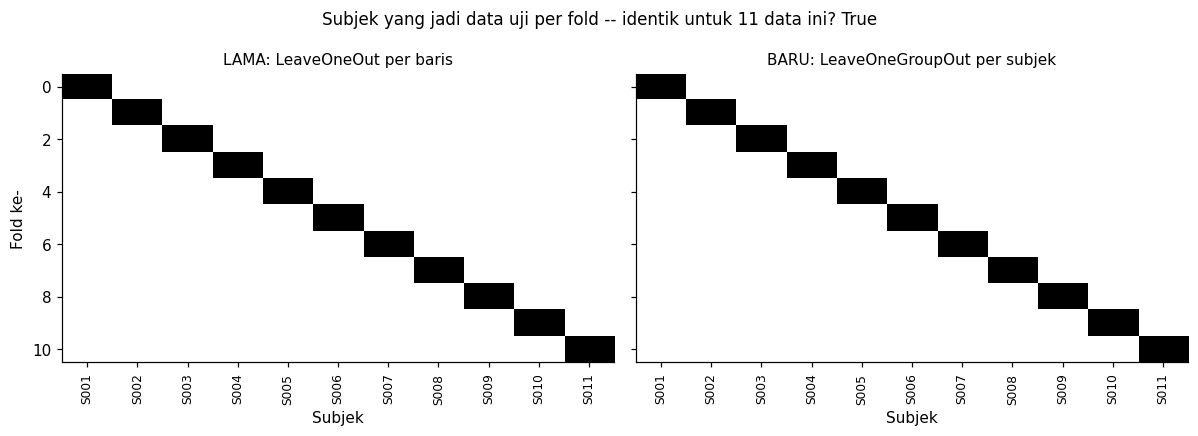

Jumlah fold LeaveOneOut()      : 11
Jumlah fold LeaveOneGroupOut() : 11
Pembagian fold identik untuk 11 data ini? True

-> Makanya perbaikan ini TIDAK mengubah angka metrik untuk 11 data yang ada sekarang.
   Manfaatnya baru terasa begitu ada subjek yang direkam lebih dari sekali.


In [2]:
X_demo = df[FEATURES].fillna(df[FEATURES].median()).values
y_demo = df["sistolik_mmhg"].fillna(df["sistolik_mmhg"].median()).values
groups_demo = df["subject_id"].values
subjek_urut = sorted(df["subject_id"].unique())

loo_folds = list(LeaveOneOut().split(X_demo))
logo_folds = list(LeaveOneGroupOut().split(X_demo, y_demo, groups_demo))

def matriks_uji(folds, subjek_per_baris):
    m = np.zeros((len(folds), len(subjek_urut)))
    for fold_i, (_, idx_uji) in enumerate(folds):
        for baris in idx_uji:
            kolom = subjek_urut.index(subjek_per_baris[baris])
            m[fold_i, kolom] = 1
    return m

m_lama = matriks_uji(loo_folds, groups_demo)
m_baru = matriks_uji(logo_folds, groups_demo)
identik = np.array_equal(m_lama, m_baru)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m, judul in zip(axes, [m_lama, m_baru], ["LAMA: LeaveOneOut per baris", "BARU: LeaveOneGroupOut per subjek"]):
    ax.imshow(m, cmap="Greys", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(subjek_urut)))
    ax.set_xticklabels(subjek_urut, rotation=90, fontsize=8)
    ax.set_title(judul, fontsize=10)
    ax.set_xlabel("Subjek")
axes[0].set_ylabel("Fold ke-")
fig.suptitle(f"Subjek yang jadi data uji per fold -- identik untuk 11 data ini? {identik}", fontsize=11)
fig.tight_layout()
plt.show()

print(f"Jumlah fold LeaveOneOut()      : {len(loo_folds)}")
print(f"Jumlah fold LeaveOneGroupOut() : {len(logo_folds)}")
print(f"Pembagian fold identik untuk 11 data ini? {identik}")
print()
print("-> Makanya perbaikan ini TIDAK mengubah angka metrik untuk 11 data yang ada sekarang.")
print("   Manfaatnya baru terasa begitu ada subjek yang direkam lebih dari sekali.")

## 2. Kenapa perbaikan ini tetap penting: ilustrasi dengan data sintetis

**Data di bawah ini BUKAN data asli relawan** -- empat subjek asli digandakan dua kali dengan sedikit
derau acak untuk mensimulasikan skenario "direkam dua kali" (persis situasi yang akan terjadi setelah
pengujian ke-6 dan ke-7 menambah data pada subjek yang sudah ada). Tujuannya cuma menunjukkan
**mekanisme kebocorannya** secara konkret, bukan mengklaim performa model yang sebenarnya.

Grafik prediksi vs nilai sebenarnya di bawah memperjelas bedanya: pada skema lama, titik-titik hasil
prediksi menempel nyaris sempurna di garis diagonal (model "menyontek" dari baris kembarannya sendiri
yang bocor ke data latih). Pada skema baru, titik-titiknya tersebar jauh dari garis diagonal --
lebih buruk terlihat, tapi itu justru **angka yang jujur**, karena model benar-benar dites terhadap
orang yang belum pernah ia lihat sama sekali.

Data ilustrasi: 8 baris dari 4 orang (masing-masing 'direkam' 2 kali, dengan sedikit derau)


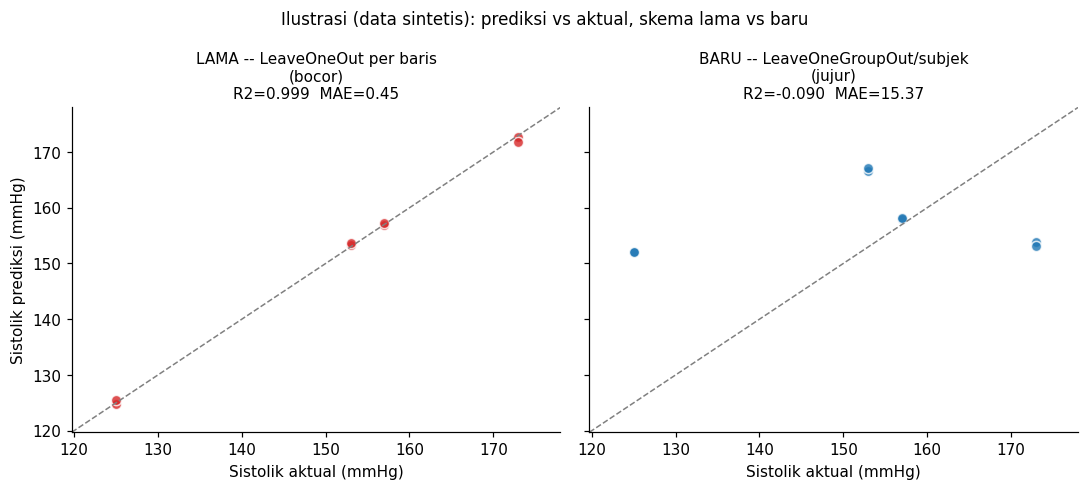

Skema                                   R2         MAE
LAMA -- LeaveOneOut per baris        0.999       0.455  <- bocor, cenderung lebih optimis
BARU -- LeaveOneGroupOut/subjek     -0.090      15.368  <- jujur, subjek yg sama tidak pernah dites dari dirinya sendiri


In [3]:
rng = np.random.default_rng(42)
subset = df[df["subject_id"].isin(df["subject_id"].unique()[:4])].copy()

duplikat = subset.copy()
for col in FEATURES:
    if pd.api.types.is_numeric_dtype(duplikat[col]):
        derau = rng.normal(0, 0.01, size=len(duplikat)) * duplikat[col].abs().clip(lower=1)
        duplikat[col] = duplikat[col] + derau
duplikat["subject_id"] = duplikat["subject_id"] + "_sesi2"
duplikat["_subjek_asli"] = subset["subject_id"].values

ilustrasi = pd.concat([
    subset.assign(_subjek_asli=subset["subject_id"].values),
    duplikat,
], ignore_index=True)

print(f"Data ilustrasi: {len(ilustrasi)} baris dari {ilustrasi['_subjek_asli'].nunique()} orang "
      f"(masing-masing 'direkam' 2 kali, dengan sedikit derau)")

Xi = ilustrasi[FEATURES].fillna(ilustrasi[FEATURES].median()).values
yi = ilustrasi["sistolik_mmhg"].fillna(ilustrasi["sistolik_mmhg"].median()).values
Xi = StandardScaler().fit_transform(Xi)

mlp_kwargs = dict(hidden_layer_sizes=(4,), activation="relu", solver="lbfgs",
                   alpha=1.0, max_iter=5000, random_state=42)

pred_lama = cross_val_predict(MLPRegressor(**mlp_kwargs), Xi, yi, cv=LeaveOneOut())
r2_lama = r2_score(yi, pred_lama)
mae_lama = mean_absolute_error(yi, pred_lama)

pred_baru = cross_val_predict(MLPRegressor(**mlp_kwargs), Xi, yi,
                               cv=LeaveOneGroupOut(), groups=ilustrasi["_subjek_asli"].values)
r2_baru = r2_score(yi, pred_baru)
mae_baru = mean_absolute_error(yi, pred_baru)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
lims = [min(yi.min(), pred_lama.min(), pred_baru.min()) - 5, max(yi.max(), pred_lama.max(), pred_baru.max()) + 5]
for ax, pred, r2, mae, judul, warna in zip(
    axes, [pred_lama, pred_baru], [r2_lama, r2_baru], [mae_lama, mae_baru],
    ["LAMA -- LeaveOneOut per baris\n(bocor)", "BARU -- LeaveOneGroupOut/subjek\n(jujur)"],
    ["tab:red", "tab:blue"],
):
    ax.plot(lims, lims, "--", color="grey", linewidth=1, label="prediksi = aktual")
    ax.scatter(yi, pred, color=warna, s=45, alpha=0.8, edgecolor="white")
    ax.set_title(f"{judul}\nR2={r2:.3f}  MAE={mae:.2f}", fontsize=10)
    ax.set_xlabel("Sistolik aktual (mmHg)")
    ax.set_xlim(lims); ax.set_ylim(lims)
axes[0].set_ylabel("Sistolik prediksi (mmHg)")
fig.suptitle("Ilustrasi (data sintetis): prediksi vs aktual, skema lama vs baru", fontsize=11)
fig.tight_layout()
plt.show()

print(f"{'Skema':<32}{'R2':>10}{'MAE':>12}")
print(f"{'LAMA -- LeaveOneOut per baris':<32}{r2_lama:>10.3f}{mae_lama:>12.3f}  <- bocor, cenderung lebih optimis")
print(f"{'BARU -- LeaveOneGroupOut/subjek':<32}{r2_baru:>10.3f}{mae_baru:>12.3f}  <- jujur, subjek yg sama tidak pernah dites dari dirinya sendiri")

## 3. Pelatihan ulang model produksi dengan 11 subjek kalibrasi asli (LOSO)

Kode di bawah mereplikasi persis logika `api/main.py::calibrate_train()`: kapasitas model MLP
menyesuaikan jumlah data (untuk 11 baris -> `hidden_layer_sizes=(16,8)`, `solver="lbfgs"`), dan skema
validasi silang menyesuaikan jumlah subjek (untuk 1 rekaman/subjek -> jatuh ke `LeaveOneOut()`, yang
secara matematis sama dengan LOSO seperti dibuktikan di bagian 1). Solver `lbfgs` yang dipakai
produksi tidak menyimpan kurva loss per iterasi di scikit-learn (beda dengan solver `adam`/`sgd`),
jadi bagian ini tidak menampilkan grafik loss training -- melainkan grafik yang lebih relevan untuk
data sekecil ini: **seberapa dekat prediksi model terhadap nilai sebenarnya, per subjek, per
parameter**, dari hasil evaluasi Leave-One-Subject-Out yang sesungguhnya.

In [4]:
hasil = []
prediksi_per_target = {}

for target_col, label in TARGETS.items():
    sub = df[df[target_col].notna()].copy()
    sub = sub[sub[FEATURES].notna().all(axis=1)]
    if len(sub) < 5:
        continue

    X = sub[FEATURES].values.astype(float)
    y = sub[target_col].values.astype(float)
    n = len(y)
    groups = sub["subject_id"].values
    n_subj = sub["subject_id"].nunique()

    Xs = StandardScaler().fit_transform(X)

    if n < 10:
        kwargs = dict(hidden_layer_sizes=(4,), activation="relu", solver="lbfgs",
                       alpha=1.0, max_iter=5000, random_state=42)
    elif n < 30:
        kwargs = dict(hidden_layer_sizes=(16, 8), activation="relu", solver="lbfgs",
                       alpha=0.1, max_iter=3000, random_state=42)
    else:
        kwargs = dict(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                       alpha=0.01, max_iter=500, random_state=42, learning_rate_init=0.01,
                       early_stopping=True, n_iter_no_change=15, validation_fraction=0.1)

    cv_groups = None
    if n_subj < n and n_subj >= 2:
        if n_subj >= 5:
            cv, cv_label = GroupKFold(n_splits=min(5, n_subj)), "GroupKFold/subjek"
        else:
            cv, cv_label = LeaveOneGroupOut(), "LOGO/subjek"
        cv_groups = groups
    elif n < 30:
        cv, cv_label = LeaveOneOut(), "LOO (=LOSO, 1 rekaman/subjek)"
    else:
        cv, cv_label = 5, "5-fold"

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y_cv = cross_val_predict(MLPRegressor(**kwargs), Xs, y, cv=cv, groups=cv_groups)

    mae = mean_absolute_error(y, y_cv)
    rmse = float(np.sqrt(np.mean((y - y_cv) ** 2)))
    r2 = r2_score(y, y_cv)
    pct_err = float(np.mean(np.abs(y - y_cv) / np.maximum(np.abs(y), 1e-9)) * 100)
    acc = round(100 - pct_err, 2)

    hasil.append({
        "Parameter": label, "N": n, "N Subjek": n_subj, "Skema Validasi": cv_label,
        "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4), "Akurasi (%)": acc,
    })
    prediksi_per_target[label] = (sub["subject_id"].values, y, y_cv)

hasil_df = pd.DataFrame(hasil)
hasil_df

,Parameter,N,N Subjek,Skema Validasi,MAE,RMSE,R2,Akurasi (%)
0,Gula Darah (mg/dL),11,11,"LOO (=LOSO, 1 rekaman/subjek)",92.58,105.45,-7.4045,28.58
1,Kolesterol (mg/dL),11,11,"LOO (=LOSO, 1 rekaman/subjek)",56.04,75.89,-6.4336,74.62
2,Asam Urat (mg/dL),11,11,"LOO (=LOSO, 1 rekaman/subjek)",1.48,1.96,-3.2663,69.64
3,Sistolik (mmHg),11,11,"LOO (=LOSO, 1 rekaman/subjek)",54.06,61.13,-13.2700,61.64
4,Diastolik (mmHg),11,11,"LOO (=LOSO, 1 rekaman/subjek)",30.94,36.81,-7.6501,60.06


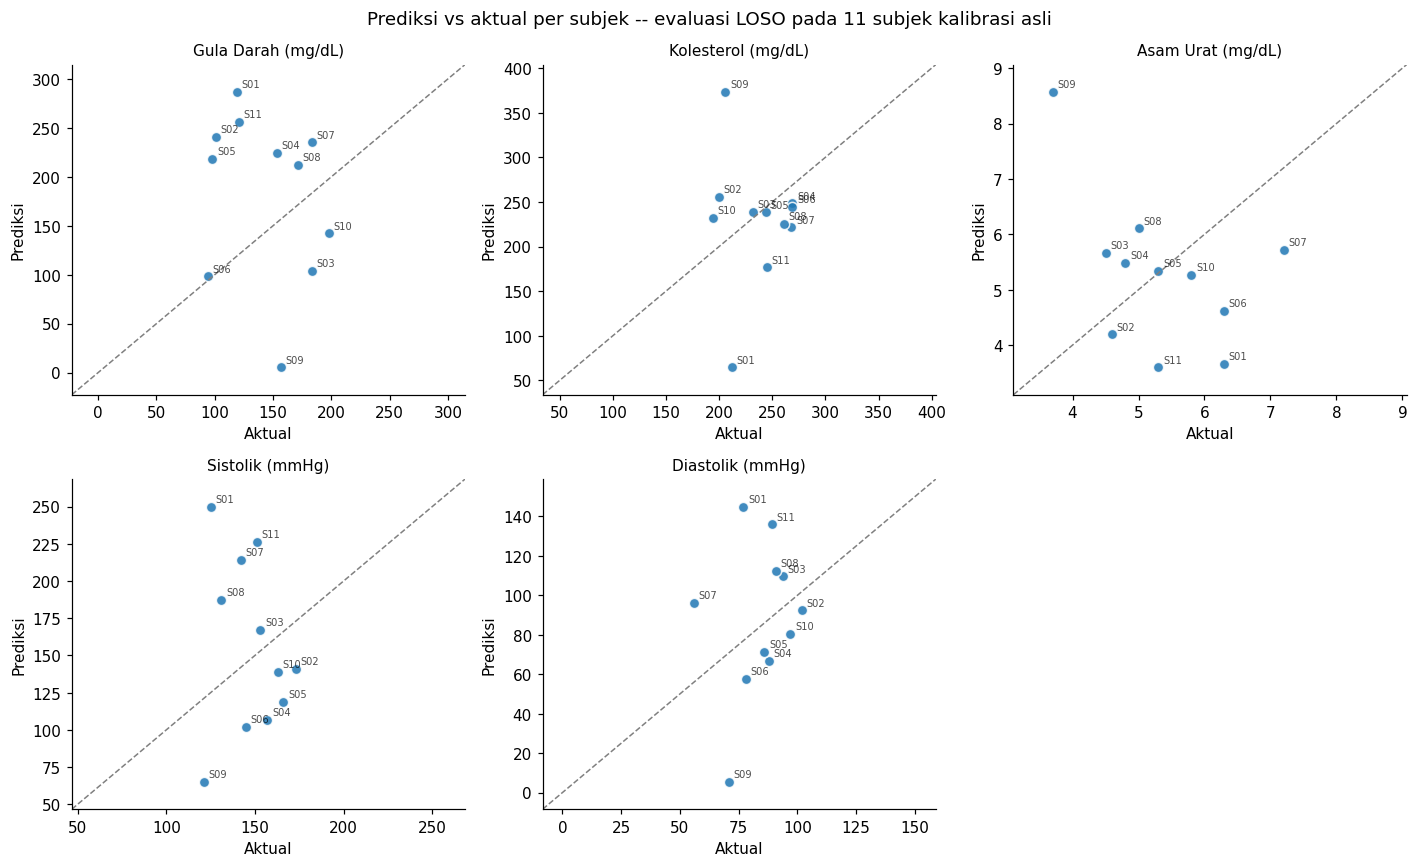

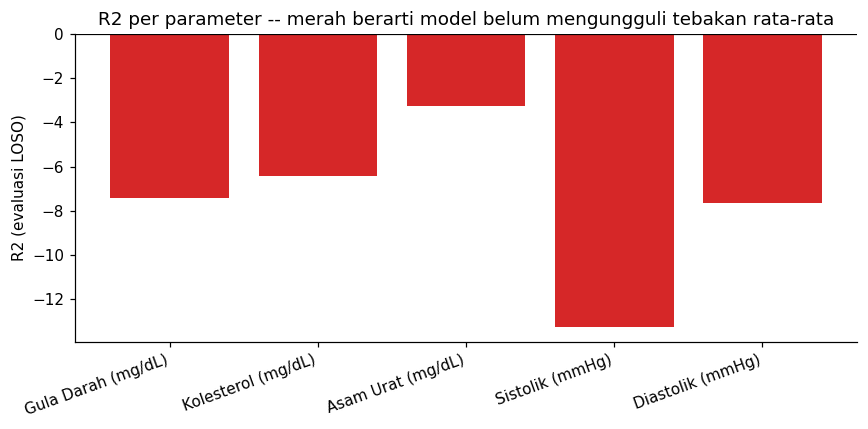

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for ax, (label, (subj, y_asli, y_pred)) in zip(axes, prediksi_per_target.items()):
    lims = [min(y_asli.min(), y_pred.min()), max(y_asli.max(), y_pred.max())]
    pad = (lims[1] - lims[0]) * 0.1 or 1
    lims = [lims[0] - pad, lims[1] + pad]
    ax.plot(lims, lims, "--", color="grey", linewidth=1)
    ax.scatter(y_asli, y_pred, color="tab:blue", s=45, alpha=0.85, edgecolor="white")
    for xi, yi_, s in zip(y_asli, y_pred, subj):
        ax.annotate(s.replace("S0", "S"), (xi, yi_), fontsize=6.5, alpha=0.7,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Aktual"); ax.set_ylabel("Prediksi")
axes[-1].axis("off")
fig.suptitle("Prediksi vs aktual per subjek -- evaluasi LOSO pada 11 subjek kalibrasi asli", fontsize=12)
fig.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
warna_bar = ["tab:red" if r < 0 else "tab:green" for r in hasil_df["R2"]]
ax2.bar(hasil_df["Parameter"], hasil_df["R2"], color=warna_bar)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("R2 (evaluasi LOSO)")
ax2.set_title("R2 per parameter -- merah berarti model belum mengungguli tebakan rata-rata")
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")
fig2.tight_layout()
plt.show()

## Ringkasan

- Skema validasi silang MLP sekarang dikelompokkan per `subject_id` (LOSO), bukan per baris rekaman --
  mencegah kebocoran data antar-sesi milik relawan yang sama.
- Untuk 11 subjek kalibrasi saat ini (1 rekaman/subjek), skema lama dan baru **memberi angka metrik
  yang sama persis**, dibuktikan langsung lewat matriks fold di bagian 1 -- perbaikan ini tidak
  mengubah angka yang sudah dilaporkan sebelumnya, murni penguatan metodologi untuk data yang akan
  datang.
- Ilustrasi sintetis (bagian 2) menunjukkan skema lama BISA menghasilkan metrik yang lebih optimis
  secara palsu (R2 mendekati sempurna di grafik kiri) begitu ada subjek dengan lebih dari satu
  rekaman -- persis situasi yang akan muncul setelah pengujian ke-6 dan ke-7 (lihat Rencana Tahapan
  Berikutnya, BAB 6).
- Grafik prediksi-vs-aktual pada bagian 3 memperlihatkan R2 negatif di hampir semua parameter pada
  evaluasi LOSO 11 subjek asli -- angka ini dilaporkan apa adanya sebagai keterbatasan yang jujur,
  konsisten dengan temuan evaluasi-evaluasi sebelumnya bahwa 11 subjek belum cukup bagi MLP untuk
  benar-benar belajar pola dari sinyal PPG.
- Perbaikan metodologi ini sudah aktif di `api/main.py` (endpoint `/v1/calibrate/train`) dan
  direplikasi di notebook ini untuk dokumentasi.